In [1]:
from google.colab import drive
drive.mount('/content/drive')
GDRIVE_DATA_DIR = "/content/drive/MyDrive/"


Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np
from PIL import Image
import os

In [ ]:
!pip install datasets==3.6.0
!pip install modelscope==1.28.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 9.3 MB/s eta 0:00:00
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 59.3 MB/s eta 0:00:00


**IMPORTING DRAGON INTO DRIVE**

In [ ]:
import os
from tqdm import tqdm
from datasets import load_dataset

def import_dragon(size="ExtraSmall", max_train=None, max_test=None):
    """
    Import DRAGON dataset images into Google Drive.

    Output structure:
        datasets/Dragon/
            train/
            test/
    """

    base_dir = os.path.join(GDRIVE_DATA_DIR, "datasets", "Dragon")
    train_dir = os.path.join(base_dir, "train")
    test_dir = os.path.join(base_dir, "test")

    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(test_dir, exist_ok=True)

    print(f"Loading DRAGON ({size})...")
    ds = load_dataset("lesc-unifi/dragon", size)

    def save_split(split, out_dir, max_images):
        for i, sample in enumerate(tqdm(split)):
            if max_images is not None and i >= max_images:
                break

            image = sample["png"]
            if image.mode != "RGB":
                image = image.convert("RGB")

            image.save(os.path.join(out_dir, f"{i:07d}.jpg"))

    if "train" in ds:
        save_split(ds["train"], train_dir, max_train)

    if "test" in ds:
        save_split(ds["test"], test_dir, max_test)

    print(f"Done. Saved to {base_dir}")


In [ ]:
import_dragon(size="ExtraSmall", max_train=100, max_test=50)


Loading DRAGON (ExtraSmall)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train/xs/dragon_train_xs.tar:   0%|          | 0.00/326M [00:00<?, ?B/s]

test/dragon_test_00.tar:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

  5%|▌         | 50/1000 [00:02<00:40, 23.36it/s]

Done. Saved to /content/drive/MyDrive/datasets/Dragon


In [ ]:
# downloading already taken care of, saved in datasets folder in drive and mounted above

**GENERATE DATALOADER AND TESTLOADER - set for Wildfake rn**

In [ ]:
# import os
# import random

# # train_dir = '/content/drive/MyDrive/datasets/OpenFake/train'
# train_dir = '/content/drive/MyDrive/datasets/wildfake_2k_split/train'
# real_dir = os.path.join(train_dir, 'real')
# fake_dir = os.path.join(train_dir, 'fake')

# num_images = 1500

# real_images = [os.path.join(real_dir, fname) for fname in os.listdir(real_dir) if fname.endswith(('.jpg', '.png', '.jpeg'))]
# fake_images = [os.path.join(fake_dir, fname) for fname in os.listdir(fake_dir) if fname.endswith(('.jpg', '.png', '.jpeg'))]

# # Ensure that we don't try to sample more images than available
# selected_real_images = random.sample(real_images, min(num_images, len(real_images)))
# selected_fake_images = random.sample(fake_images, min(num_images, len(fake_images)))

# # Combine them into a list of selected images with their labels
# selected_images = selected_real_images + selected_fake_images
# labels = [0] * len(selected_real_images) + [1] * len(selected_fake_images)

# print(f"Selected {len(selected_real_images)} real images and {len(selected_fake_images)} fake images.")

Selected 800 real images and 800 fake images.


In [ ]:
# import torch
# from torchvision import transforms
# from torch.utils.data import Dataset, DataLoader
# from PIL import Image

# class OpenFakeDataset(Dataset):
#     def __init__(self, image_paths, labels, transform=None):
#         self.image_paths = image_paths
#         self.labels = labels
#         self.transform = transform

#     def __len__(self):
#         return len(self.image_paths)

#     def __getitem__(self, idx):
#         img_path = self.image_paths[idx]
#         image = Image.open(img_path).convert("RGB")
#         label = self.labels[idx]

#         if self.transform:
#             image = self.transform(image)

#         return image, label

# # Image transformations
# transform = transforms.Compose([
#     transforms.Resize((224, 224)),    # Resize to match ViT's input size
#     transforms.ToTensor(),            # Convert image to tensor
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize with ImageNet stats that the ViT was trained on
# ])


# dataset = OpenFakeDataset(selected_images, labels, transform=transform)
# dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

# test_dataset = OpenFakeDataset(test_dir, transform=transform)
# test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, collate_fn=collate)


NameError: name 'OpenFakeTestDataset' is not defined

**PREPROCESS FUNCTIONS + GENERATE TEST/TRAIN LOADERS**

In [2]:
# ============================
# Full Preprocessing + Dataset
# ============================

from dataclasses import dataclass
from typing import Dict, List, Tuple
from pathlib import Path
import os
import numpy as np
from PIL import Image, ImageOps

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

import random

from datasets import load_dataset

# -----------------------------
# Normalization constants
# -----------------------------
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)
CLIP_MEAN     = (0.48145466, 0.4578275, 0.40821073)
CLIP_STD      = (0.26862954, 0.26130258, 0.27577711)

@dataclass
class PreprocessConfig:
    vit_size: int = 224            # ViT input size
    cnn_patch: int = 224           # patch size for CNN 'spatial expert'
    patch_stride: float = 0.5      # overlap fraction (0.5 = 50%)
    normalize: str = "imagenet"    # "imagenet" or "clip"
    ycbcr_for_fft: bool = True
    windowing: str = "hann"
    preserve_exif_orientation: bool = True
    max_long_side: int = 4096

def resize_keep_ar(img: Image.Image, long_side: int) -> Image.Image:
    """Downscale large images while preserving aspect ratio."""
    w, h = img.size
    m = max(w, h)
    if m <= long_side:
        return img.copy()
    scale = long_side / float(m)
    new_size = (int(round(w * scale)), int(round(h * scale)))
    return img.resize(new_size, resample=Image.BICUBIC, reducing_gap=2.0)

def _norm_transform(scheme: str):
    if scheme.lower() == "clip":
        return T.Normalize(CLIP_MEAN, CLIP_STD)
    return T.Normalize(IMAGENET_MEAN, IMAGENET_STD)

def make_vit_tensor(img: Image.Image, size: int, scheme: str):
    # resize shortest side, center crop, to tensor, normalize
    t = T.Compose([
        T.Resize(size, interpolation=T.InterpolationMode.BICUBIC, antialias=True),
        T.CenterCrop((size, size)),
        T.ToTensor(),
        _norm_transform(scheme),
    ])
    return t(img)

def extract_patches(img: Image.Image, patch: int, stride_ratio: float) -> Tuple[List[Image.Image], List[int], List[int]]:
    """Sliding-window patch extraction with overlap."""
    W, H = img.size
    stride = max(1, int(round(patch * stride_ratio)))
    xs = list(range(0, max(W - patch, 0) + 1, stride))
    ys = list(range(0, max(H - patch, 0) + 1, stride))
    if not xs: xs = [0]
    if not ys: ys = [0]
    patches = []
    for y in ys:
        for x in xs:
            crop = img.crop((x, y, x + patch, y + patch))
            if crop.size != (patch, patch):
                pad = Image.new("RGB", (patch, patch))
                pad.paste(crop, (0, 0))
                crop = pad
            patches.append(crop)
    return patches, xs, ys

def ycbcr_channels(img: Image.Image):
    ycbcr = img.convert("YCbCr")
    Y, Cb, Cr = ycbcr.split()
    return Y, Cb, Cr

def _window(arr: np.ndarray, kind: str):
    h, w = arr.shape[:2]
    if kind == "hann":
        wy = np.hanning(h)[:, None]
        wx = np.hanning(w)[None, :]
        return wy * wx
    if kind == "hamming":
        wy = np.hamming(h)[:, None]
        wx = np.hamming(w)[None, :]
        return wy * wx
    return np.ones((h, w), dtype=arr.dtype)

def fft_log_magnitude(gray_img: Image.Image, window: str = "hann") -> Image.Image:
    """Compute log-magnitude FFT spectrum as a single-channel image in [0,255]."""
    arr = np.array(gray_img).astype(np.float32) / 255.0
    win = _window(arr, window)
    F = np.fft.fft2(arr * win)
    Fshift = np.fft.fftshift(F)
    mag = np.log1p(np.abs(Fshift))
    mag = (mag - mag.mean()) / (mag.std() + 1e-6)
    mag = (mag - mag.min()) / (mag.max() - mag.min() + 1e-6)
    return Image.fromarray((mag * 255).astype(np.uint8))

def patches_to_tensor(patches: List[Image.Image], scheme: str):
    t = T.Compose([
        T.ToTensor(),
        _norm_transform(scheme),
    ])
    return torch.stack([t(p) for p in patches], dim=0)

def preprocess_all(path: str, cfg: PreprocessConfig = PreprocessConfig()) -> Dict:
    """Full pipeline for one image: returns vit, cnn_patches, fft_tensor, meta."""
    img = Image.open(path)
    if cfg.preserve_exif_orientation:
        img = ImageOps.exif_transpose(img)
    img = img.convert("RGB")

    # resize if huge
    img = resize_keep_ar(img, cfg.max_long_side)

    # ViT input
    vit_tensor = make_vit_tensor(img, cfg.vit_size, "imagenet")

    # CNN patches
    patches, xs, ys = extract_patches(img, cfg.cnn_patch, cfg.patch_stride)
    cnn_patches = patches_to_tensor(patches, "imagenet")

    # FFT on luminance
    Y, Cb, Cr = ycbcr_channels(img.resize((cfg.cnn_patch, cfg.cnn_patch), Image.BICUBIC))
    fft_img = fft_log_magnitude(Y, cfg.windowing)
    fft_tensor = T.ToTensor()(fft_img)  # [1, H, W]

    return {
        "vit": vit_tensor,
        "cnn_patches": cnn_patches,
        "fft_tensor": fft_tensor,
        "meta": {
            "grid_x": xs,
            "grid_y": ys,
            "patch_size": cfg.cnn_patch,
            "stride_ratio": cfg.patch_stride,
        }
    }

# --- NEW: same preprocessing but starting from a PIL image (HF gives PIL, not file paths) ---
def preprocess_pil(img: Image.Image, cfg: PreprocessConfig = PreprocessConfig()) -> Dict:
    """Full pipeline for one image: returns vit, cnn_patches, fft_tensor, meta."""
    if cfg.preserve_exif_orientation:
        img = ImageOps.exif_transpose(img)
    img = img.convert("RGB")

    img = resize_keep_ar(img, cfg.max_long_side)

    vit_tensor = make_vit_tensor(img, cfg.vit_size, "imagenet")

    patches, xs, ys = extract_patches(img, cfg.cnn_patch, cfg.patch_stride)
    cnn_patches = patches_to_tensor(patches, "imagenet")

    Y, Cb, Cr = ycbcr_channels(img.resize((cfg.cnn_patch, cfg.cnn_patch), Image.BICUBIC))
    fft_img = fft_log_magnitude(Y, cfg.windowing)
    fft_tensor = T.ToTensor()(fft_img)

    return {
        "vit": vit_tensor,
        "cnn_patches": cnn_patches,
        "fft_tensor": fft_tensor,
        "meta": {
            "grid_x": xs,
            "grid_y": ys,
            "patch_size": cfg.cnn_patch,
            "stride_ratio": cfg.patch_stride,
        }
    }
# ------------------------------------------------------------------------------------------

# -----------------------------
# Dataset + collate (old style)
# -----------------------------

VALID_EXT = {".jpg", ".jpeg", ".png", ".webp"}

class PreprocDataset(Dataset):
    """
    Local mode:
      Loads files from root/{real,fake}, calls preprocess_all(path),
      and attaches label: real=0, fake=1.

    HF mode:
      If root looks like "org/name" (not a filesystem path), loads a HF dataset id and expects:
        - ex["image"] : PIL.Image
        - ex["label"] : int (any)
      If force_label is set, overrides label for ALL samples (useful for "all fake" eval).
    """
    def __init__(self, root: str | Path, max_images: int | None = None, hf_split: str = "test", force_label: int | None = None):
        self.items = []
        self.is_hf = False
        self.force_label = force_label  # <-- NEW

        # --- HF MODE ---
        if isinstance(root, str) and ("/" in root) and (not root.startswith("/")):
            self.is_hf = True
            self.hf_id = root
            self.ds = load_dataset(self.hf_id, split=hf_split)
            if max_images is not None:
                self.ds = self.ds.select(range(min(max_images, len(self.ds))))
            return
        # --------------

        # --- LOCAL MODE (unchanged logic) ---
        root = Path(root)

        if max_images is not None:
            max_per_class = max_images // 2
        else:
            max_per_class = None

        for y, cls in enumerate(["real", "fake"]):
            d = root / cls
            if not d.exists():
                continue

            files = [f for f in d.iterdir() if f.suffix.lower() in VALID_EXT]

            if max_per_class is not None:
                files = random.sample(files, min(len(files), max_per_class))

            for f in files:
                self.items.append((str(f), y))

        random.shuffle(self.items)

        if not self.items:
            raise RuntimeError(f"No images found under {root}/real or {root}/fake")

    def __len__(self) -> int:
        if self.is_hf:
            return len(self.ds)
        return len(self.items)

    def __getitem__(self, idx) -> Dict:
        if self.is_hf:
            ex = self.ds[idx]
            img = ex["image"]          # PIL.Image

            # <-- NEW: override label locally if requested
            if self.force_label is not None:
                y = int(self.force_label)
            else:
                y = int(ex["label"])

            out = preprocess_pil(img)  # vit, cnn_patches, fft_tensor, meta
            out["label"] = y
            return out

        path, y = self.items[idx]
        out = preprocess_all(path)   # vit, cnn_patches, fft_tensor, meta
        out["label"] = y             # numeric label
        return out

def collate(batch: List[Dict]) -> Dict:
    """
    Returns a dict ready for models:
      - vit:    [B,3,S,S]
      - fft:    [B,1,P,P]
      - patches: list of [N_i,3,P,P]
      - labels: [B]
      - meta:   list of metadata dicts
    """
    labels = torch.tensor([b["label"] for b in batch]).long()
    vit = torch.stack([b["vit"] for b in batch])                 # [B,3,S,S]
    fft = torch.stack([b["fft_tensor"] for b in batch])          # [B,1,P,P]
    patches = [b["cnn_patches"] for b in batch]                  # list of [N_i,3,P,P]
    meta = [b["meta"] for b in batch]
    return {"vit": vit, "fft": fft, "patches": patches, "labels": labels, "meta": meta}

# -----------------------------
# Build train & test loaders
# -----------------------------

# train_dir = "/content/drive/MyDrive/datasets/OpenFake/train"
# test_dir  = "/content/drive/MyDrive/datasets/OpenFake/test"
train_dir = "/content/drive/MyDrive/datasets/wildfake_2k_split/train"

# HF test example:
# test_dir = "DeepFakeDetector/manual-gen-images"
# hf_split = "test"  # or "validation"

# Local test example:
test_dir  = "/content/drive/MyDrive/datasets/wildfake_2k_split/test"

# Use max_images=None for full set, or e.g. max_images=1000 to limit
train_dataset = PreprocDataset(train_dir, max_images=2000)
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=collate,
)

# if test_dir is HF id, pass hf_split; if local path, hf_split is ignored
test_dataset = PreprocDataset(test_dir, max_images=1000, hf_split="test")
test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=collate,
)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples:  {len(test_dataset)}")

Train samples: 1600
Test samples:  400


**CREATE MODEL**

In [ ]:
from timm import create_model
import torch.nn as nn

model = create_model("deit_small_patch16_224", pretrained=True)

# Get the number of input features to the final layer
num_ftrs = model.num_features

# Create a new classification head with 2 output classes (real, fake)
model.head = nn.Linear(num_ftrs, 2)

model.eval()
print(model)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device selected:", device)

if device.type == "cuda":
    print("GPU Name:", torch.cuda.get_device_name(0))

model = model.to(device)

x = torch.randn(1, 3, 224, 224).to(device)
print("Tensor is on:", x.device)


Device selected: cuda
GPU Name: NVIDIA L4
Tensor is on: cuda:0


Unfreezing entire ViT backbone...

=== Training UNFROZEN backbone (fine-tuning) ===

Epoch 1/2


100%|██████████| 125/125 [27:04<00:00, 13.00s/it]


Fine-Tune Loss: 0.6503, Acc: 61.60%

Epoch 2/2


100%|██████████| 125/125 [01:41<00:00,  1.24it/s]


Fine-Tune Loss: 0.3696, Acc: 86.15%

=== Evaluating fine-tuned model ===


100%|██████████| 62/62 [12:57<00:00, 12.53s/it]


=== Fine-Tuned Results ===
Accuracy: 78.32%
Sensitivity (Fake TPR): 0.82
Specificity (Fake TNR): 0.74
PPV (Fake Precision): 0.77
NPV: 0.80
Average Loss: 0.4571

Classification Report (0=Real, 1=Fake):
              precision    recall  f1-score   support

           0     0.8009    0.7406    0.7696       478
           1     0.7687    0.8240    0.7954       500

    accuracy                         0.7832       978
   macro avg     0.7848    0.7823    0.7825       978
weighted avg     0.7844    0.7832    0.7828       978



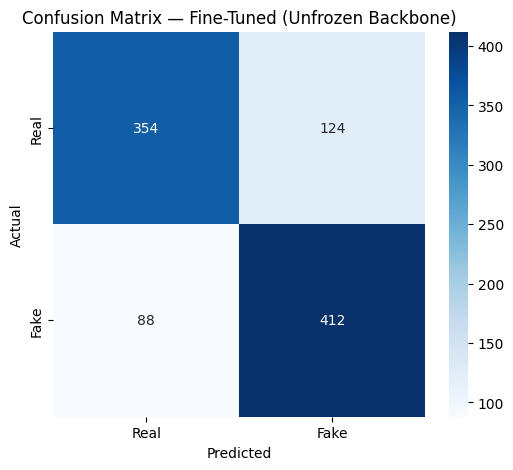

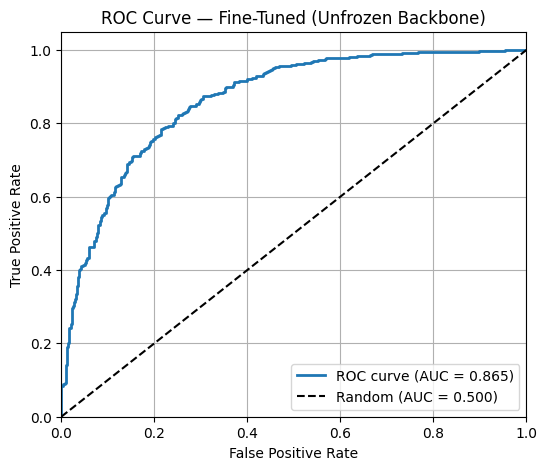

In [ ]:
#######################
# UNFROZEN BACKBONE
#######################

import torch
from torch import nn
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# =====================
# Unfreeze backbone
# =====================
print("Unfreezing entire ViT backbone...")
for param in model.parameters():
    param.requires_grad = True

# ====================================
# Define optimizer for full model
# ====================================
optimizer = AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

fine_tune_epochs = 2
model.to(device)

# =============================
# Fine-tuning training loop
# =============================
print("\n=== Training UNFROZEN backbone (fine-tuning) ===")

for epoch in range(fine_tune_epochs):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    print(f"\nEpoch {epoch+1}/{fine_tune_epochs}")

    # NOTE: use train_loader (not dataloader)
    for batch in tqdm(train_loader):
        images = batch["vit"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    epoch_loss = running_loss / max(total_samples, 1)
    epoch_acc = running_correct / max(total_samples, 1) * 100
    print(f"Fine-Tune Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.2f}%")

# ============================
# Evaluate fine-tuned model
# ============================
print("\n=== Evaluating fine-tuned model ===")

model.eval()
all_labels_ft = []
all_preds_ft = []
all_probs_ft = []
eval_loss = 0.0
total_samples = 0

with torch.no_grad():
    for batch in tqdm(test_loader):
        images = batch["vit"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        eval_loss += loss.item() * images.size(0)
        total_samples += labels.size(0)

        # class 1 prob (your setup: real=0, fake=1)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = outputs.argmax(dim=1)

        all_labels_ft.extend(labels.cpu().numpy())
        all_preds_ft.extend(preds.cpu().numpy())
        all_probs_ft.extend(probs.cpu().numpy())

avg_loss = eval_loss / max(total_samples, 1)
acc = accuracy_score(all_labels_ft, all_preds_ft)

# Confusion matrix: rows=true [0=Real,1=Fake], cols=pred [0=Real,1=Fake]
cm = confusion_matrix(all_labels_ft, all_preds_ft)
tn, fp, fn, tp = cm.ravel()

# Metrics treating "Fake" (label=1) as the positive class
sensitivity = tp / (tp + fn + 1e-8)  # TPR for fake
specificity = tn / (tn + fp + 1e-8)  # TNR for fake (i.e., correctly real)
ppv = tp / (tp + fp + 1e-8)          # precision for fake
npv = tn / (tn + fn + 1e-8)

print("\n=== Fine-Tuned Results ===")
print(f"Accuracy: {acc * 100:.2f}%")
print(f"Sensitivity (Fake TPR): {sensitivity:.2f}")
print(f"Specificity (Fake TNR): {specificity:.2f}")
print(f"PPV (Fake Precision): {ppv:.2f}")
print(f"NPV: {npv:.2f}")
print(f"Average Loss: {avg_loss:.4f}\n")
print("Classification Report (0=Real, 1=Fake):")
print(classification_report(all_labels_ft, all_preds_ft, digits=4))

# ====================
# Confusion Matrix
# ====================
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Real", "Fake"],
    yticklabels=["Real", "Fake"]
)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix — Fine-Tuned (Unfrozen Backbone)")
plt.show()

# ============
# ROC Curve
# ============
fpr_ft, tpr_ft, _ = roc_curve(all_labels_ft, all_probs_ft)  # positive class = 1 (Fake)
roc_auc_ft = auc(fpr_ft, tpr_ft)

plt.figure(figsize=(6, 5))
plt.plot(fpr_ft, tpr_ft, label=f"ROC curve (AUC = {roc_auc_ft:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.500)")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Fine-Tuned (Unfrozen Backbone)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [ ]:
checkpoint = {
    "model": model.state_dict(),                       # entire model object
    "optimizer_state": optimizer.state_dict(),
    "epoch": epoch
}

torch.save(checkpoint, "/content/drive/MyDrive/DeepfakeDetectionModels/vit_transfer_baseline_deit_unfrozen_backbone_78%.pth")
print("Saved full model checkpoint.")


Saved full model checkpoint.




Verifying Labels to Debug

In [ ]:
import numpy as np
print("Unique preds:", np.unique(all_preds_ft, return_counts=True))
print("Unique labels:", np.unique(all_labels_ft, return_counts=True))


Unique preds: (array([0, 1]), array([504, 496]))
Unique labels: (array([0, 1]), array([478, 522]))


In [ ]:
from collections import Counter
print("Train label counts:", Counter([y for _, y in train_dataset.items]))
print("Test label counts:", Counter([y for _, y in test_dataset.items]))


Train label counts: Counter({0: 200, 1: 200})
Test label counts: Counter({1: 522, 0: 478})



**Fine-Tune #3 - Distilled Deit Model Training/Testing with OpenFake**

In [ ]:
# ============================================================
# DeiT-Base Distilled (timm) + Custom 2-class head
# ============================================================

from timm import create_model
import torch
import torch.nn as nn
from torch.optim import AdamW

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------
# Model
# ---------
model = create_model("deit_base_distilled_patch16_224", pretrained=True)
num_ftrs = model.num_features

# Custom classification head (2 classes: 0=Real, 1=Fake)
head = nn.Sequential(
    nn.LayerNorm(num_ftrs),
    nn.Linear(num_ftrs, 512),
    nn.GELU(),
    nn.Dropout(0.2),
    nn.Linear(512, 2),
)

# Replace BOTH heads
model.head = head
if hasattr(model, "head_dist"):
    model.head_dist = nn.Sequential(
        nn.LayerNorm(num_ftrs),
        nn.Linear(num_ftrs, 512),
        nn.GELU(),
        nn.Dropout(0.2),
        nn.Linear(512, 2),
    )

model.to(device)

# ---------
# Unfreeze all params
# ---------
for p in model.parameters():
    p.requires_grad = True

# ---------
# Discriminative LR (backbone smaller LR, head larger LR)
# ---------
backbone_params, head_params = [], []
for name, p in model.named_parameters():
    if name.startswith("head") or name.startswith("head_dist"):
        head_params.append(p)
    else:
        backbone_params.append(p)

optimizer = AdamW(
    [
        {"params": backbone_params, "lr": 2e-5},
        {"params": head_params,     "lr": 5e-5},
    ],
    weight_decay=1e-4,
)

criterion = nn.CrossEntropyLoss()
fine_tune_epochs = 4


Using device: cuda


In [ ]:
## Training new model

print("\n=== Fine-Tuning DeiT-Base Distilled ===")

for epoch in range(fine_tune_epochs):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    print(f"\nEpoch {epoch+1}/{fine_tune_epochs}")

    for batch in tqdm(train_loader):
        images = batch["vit"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(images)

        # Distilled DeiT may return (logits, dist_logits) in training
        if isinstance(outputs, tuple):
            outputs = outputs[0]  # or (outputs[0] + outputs[1]) / 2

        loss = criterion(outputs, labels)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = running_correct / total_samples * 100
    print(f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.2f}%")



=== Fine-Tuning DeiT-Base Distilled ===

Epoch 1/4


100%|██████████| 125/125 [01:50<00:00,  1.14it/s]


Train Loss: 0.5481, Train Acc: 71.40%

Epoch 2/4


100%|██████████| 125/125 [01:50<00:00,  1.13it/s]


Train Loss: 0.2624, Train Acc: 89.25%

Epoch 3/4


100%|██████████| 125/125 [01:50<00:00,  1.13it/s]


Train Loss: 0.1015, Train Acc: 96.35%

Epoch 4/4


100%|██████████| 125/125 [01:50<00:00,  1.14it/s]

Train Loss: 0.0276, Train Acc: 99.20%


In [ ]:
## Evaluation

print("\n=== Evaluating Fine-Tuned DeiT-Base Distilled ===")

model.eval()
all_labels = []
all_preds = []
all_probs = []
eval_loss = 0.0
total_samples = 0

with torch.no_grad():
    for batch in tqdm(test_loader):
        images = batch["vit"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(images)

        # Handle possible (logits, dist_logits) in eval too
        if isinstance(outputs, tuple):
            outputs = outputs[0]

        loss = criterion(outputs, labels)

        eval_loss += loss.item() * images.size(0)
        total_samples += labels.size(0)

        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = outputs.argmax(dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

avg_loss = eval_loss / total_samples
acc = accuracy_score(all_labels, all_preds)

cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn + 1e-8)
specificity = tn / (tn + fp + 1e-8)
ppv = tp / (tp + fp + 1e-8)
npv = tn / (tn + fn + 1e-8)

print("\n=== Fine-Tuned Results ===")
print(f"Accuracy: {acc * 100:.2f}%")
print(f"Sensitivity: {sensitivity:.2f}")
print(f"Specificity: {specificity:.2f}")
print(f"PPV: {ppv:.2f}")
print(f"NPV: {npv:.2f}")
print(f"Average Loss: {avg_loss:.4f}\n")

print("Classification Report:")
print(classification_report(all_labels, all_preds, digits=4))


=== Evaluating Fine-Tuned DeiT-Base Distilled ===


100%|██████████| 62/62 [00:47<00:00,  1.32it/s]


=== Fine-Tuned Results ===
Accuracy: 85.58%
Sensitivity: 0.84
Specificity: 0.87
PPV: 0.87
NPV: 0.84
Average Loss: 0.6027

Classification Report:
              precision    recall  f1-score   support

           0     0.8390    0.8724    0.8554       478
           1     0.8732    0.8400    0.8563       500

    accuracy                         0.8558       978
   macro avg     0.8561    0.8562    0.8558       978
weighted avg     0.8565    0.8558    0.8558       978



In [ ]:
checkpoint = {
    "model": model.state_dict(),                       # entire model object
    "optimizer_state": optimizer.state_dict(),
    "epoch": epoch
}

torch.save(checkpoint, "/content/drive/MyDrive/DeepfakeDetectionModels/vit_transfer_baseline_deit_distlled_86%.pth")
print("Saved full model checkpoint.")


Saved full model checkpoint.


**Distilled Deit Model Testing on WildFake**

Create Model, Load Checkpoint (Openfake-trained Distilled Deit)

In [ ]:
# ============================================================
# Load DeiT-Base Distilled model from checkpoint (EVAL ONLY)
# ============================================================

from timm import create_model
import torch
import torch.nn as nn

# ---------
# Device
# ---------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------
# Recreate model architecture (must match training)
# ---------
model = create_model(
    "deit_base_distilled_patch16_224",
    pretrained=False
)

num_ftrs = model.num_features

# Custom classification head (2 classes)
model.head = nn.Sequential(
    nn.LayerNorm(num_ftrs),
    nn.Linear(num_ftrs, 512),
    nn.GELU(),
    nn.Dropout(0.2),
    nn.Linear(512, 2),
)

# Distillation head (must also be recreated)
if hasattr(model, "head_dist"):
    model.head_dist = nn.Sequential(
        nn.LayerNorm(num_ftrs),
        nn.Linear(num_ftrs, 512),
        nn.GELU(),
        nn.Dropout(0.2),
        nn.Linear(512, 2),
    )

# ---------
# Load checkpoint
# ---------
ckpt_path = "/content/drive/MyDrive/DeepfakeDetectionModels/vit_transfer_baseline_deit_distlled_openfake_86%.pth"

checkpoint = torch.load(ckpt_path, map_location=device)
model.load_state_dict(checkpoint["model"])

# ---------
# Ready for evaluation
# ---------
model.to(device)
model.eval()


Using device: cuda


VisionTransformerDistilled(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inpl

**Evaluate on Wildfake Test images**

In [ ]:
# Point at whichever dataset you want to evaluate on
test_dir = "/content/drive/MyDrive/datasets/wildfake_2k_split/test"

test_dataset = PreprocDataset(test_dir, max_images=1000)
test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=collate,
)

print(f"Evaluating on: {test_dir} ({len(test_dataset)} samples)")

Evaluating on: /content/drive/MyDrive/datasets/wildfake_2k_split/test (400 samples)



=== Evaluating fine-tuned model ===


100%|██████████| 25/25 [00:10<00:00,  2.48it/s]


=== Results ===
Accuracy: 72.50%
F1 (Fake=positive): 0.6802
AUC: 0.7550
Sensitivity (Fake TPR): 0.5850
Specificity (Fake TNR): 0.8650
PPV (Fake Precision): 0.8125
NPV: 0.6758
Average Loss: 0.7878

Classification Report (0=Real, 1=Fake):
              precision    recall  f1-score   support

           0     0.6758    0.8650    0.7588       200
           1     0.8125    0.5850    0.6802       200

    accuracy                         0.7250       400
   macro avg     0.7441    0.7250    0.7195       400
weighted avg     0.7441    0.7250    0.7195       400



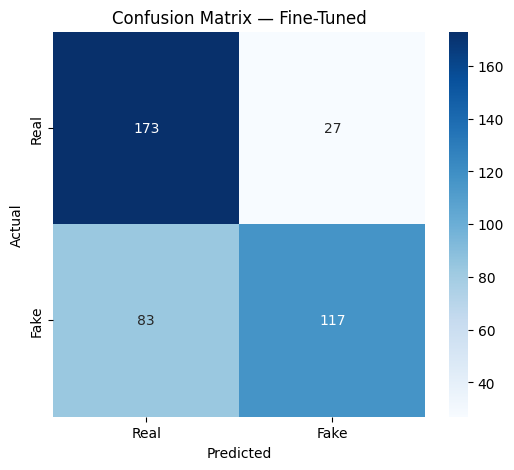

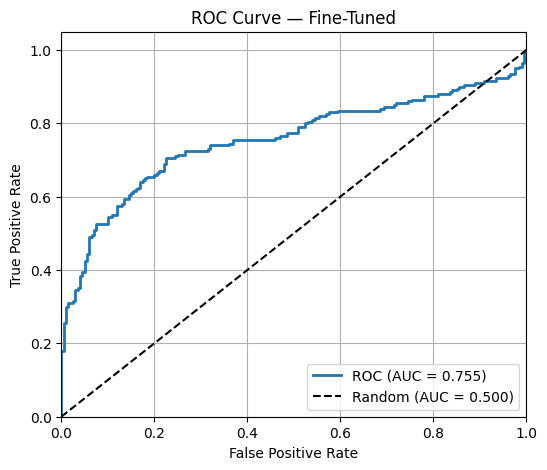

In [ ]:
# ============================
# Full Evaluation Script
# ============================

import torch
import numpy as np
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    f1_score,
)

# ----
# Make sure criterion exists
# ----
criterion = torch.nn.CrossEntropyLoss()

print("\n=== Evaluating fine-tuned model ===")
model.eval()

all_labels = []
all_preds = []
all_probs = []

eval_loss = 0.0
total_samples = 0

with torch.no_grad():
    for batch in tqdm(test_loader):
        images = batch["vit"].to(device)      # [B,3,224,224]
        labels = batch["labels"].to(device)   # [B]

        outputs = model(images)

        # DeiT distilled may output (logits, dist_logits) in some configs
        if isinstance(outputs, (tuple, list)):
            outputs = outputs[0]

        loss = criterion(outputs, labels)

        eval_loss += loss.item() * images.size(0)
        total_samples += labels.size(0)

        probs = torch.softmax(outputs, dim=1)[:, 1]   # P(class=1=Fake)
        preds = outputs.argmax(dim=1)

        all_labels.extend(labels.detach().cpu().numpy())
        all_preds.extend(preds.detach().cpu().numpy())
        all_probs.extend(probs.detach().cpu().numpy())

# ----
# Metrics
# ----
avg_loss = eval_loss / max(total_samples, 1)
acc = accuracy_score(all_labels, all_preds)
f1  = f1_score(all_labels, all_preds)  # positive class defaults to 1 in binary case

cm = confusion_matrix(all_labels, all_preds)  # rows=true, cols=pred
tn, fp, fn, tp = cm.ravel()

# Treat Fake (1) as positive
sensitivity = tp / (tp + fn + 1e-8)  # TPR
specificity = tn / (tn + fp + 1e-8)  # TNR
ppv = tp / (tp + fp + 1e-8)          # precision
npv = tn / (tn + fn + 1e-8)

# ROC + AUC
fpr, tpr, _ = roc_curve(all_labels, all_probs)  # positive class=1
roc_auc = roc_auc_score(all_labels, all_probs)

print("\n=== Results ===")
print(f"Accuracy: {acc * 100:.2f}%")
print(f"F1 (Fake=positive): {f1:.4f}")
print(f"AUC: {roc_auc:.4f}")
print(f"Sensitivity (Fake TPR): {sensitivity:.4f}")
print(f"Specificity (Fake TNR): {specificity:.4f}")
print(f"PPV (Fake Precision): {ppv:.4f}")
print(f"NPV: {npv:.4f}")
print(f"Average Loss: {avg_loss:.4f}\n")

print("Classification Report (0=Real, 1=Fake):")
print(classification_report(all_labels, all_preds, digits=4))

# ====================
# Confusion Matrix Plot
# ====================
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Real", "Fake"],
    yticklabels=["Real", "Fake"]
)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix — Fine-Tuned")
plt.show()

# ============
# ROC Curve Plot
# ============
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.500)")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Fine-Tuned")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


**Evaluate on Dragon Dataset**

In [ ]:
from huggingface_hub import login
login()  # paste your HF token when prompted

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
# login into HF above, load model

import torch
import torch.nn as nn
from timm import create_model
from huggingface_hub import hf_hub_download

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Download weights
weights_path = hf_hub_download(
    repo_id="DeepFakeDetector/deit-distilled",
    filename="deit_distilled_custom_head.pt"
)

# Recreate the exact custom MLP head from your config
def build_head(in_features=768, num_classes=2):
    return nn.Sequential(
        nn.LayerNorm(in_features),
        nn.Linear(in_features, 512),
        nn.GELU(),
        nn.Dropout(p=0.2),
        nn.Linear(512, num_classes)
    )

# Build model
model = create_model("deit_base_distilled_patch16_224", pretrained=False)

# Replace BOTH heads with the same shared MLP (as per config note)
head = build_head()
model.head = head
if hasattr(model, "head_dist"):
    model.head_dist = head  # shared weights — same object

# Load weights
state_dict = torch.load(weights_path, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()

print("Model loaded successfully")

deit_distilled_custom_head.pt:   0%|          | 0.00/346M [00:00<?, ?B/s]

Model loaded successfully


In [ ]:
# Point at whichever dataset you want to evaluate on
test_dir = "/content/drive/MyDrive/datasets/DRAGON/test"  # or any other path

test_dataset = PreprocDataset(test_dir, max_images=1000)
test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=collate,
)

print(f"Evaluating on: {test_dir} ({len(test_dataset)} samples)")

Evaluating on: /content/drive/MyDrive/datasets/DRAGON/test (188 samples)



=== Evaluating fine-tuned model ===


100%|██████████| 12/12 [00:19<00:00,  1.64s/it]


=== Results ===
Accuracy: 100.00%
F1 (Fake=positive): 1.0000
AUC: 1.0000
Sensitivity (Fake TPR): 1.0000
Specificity (Fake TNR): 1.0000
PPV (Fake Precision): 1.0000
NPV: 1.0000
Average Loss: 0.0092

Classification Report (0=Real, 1=Fake):
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000         5
           1     1.0000    1.0000    1.0000       183

    accuracy                         1.0000       188
   macro avg     1.0000    1.0000    1.0000       188
weighted avg     1.0000    1.0000    1.0000       188



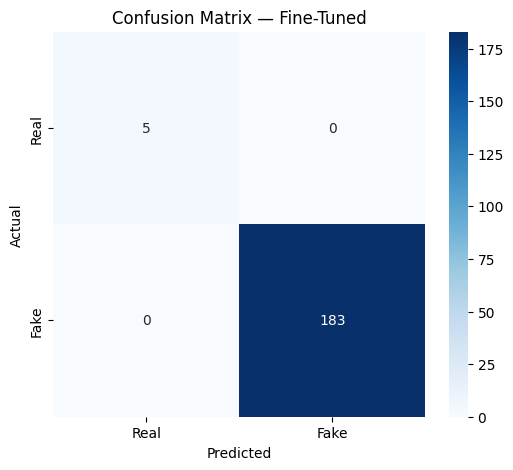

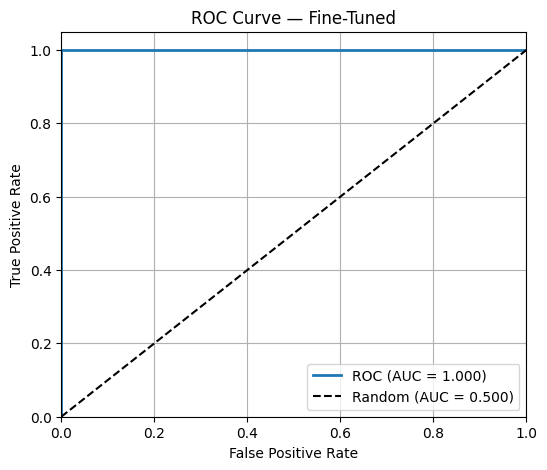

In [ ]:
# ============================
# Full Evaluation Script
# ============================

import torch
import numpy as np
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    f1_score,
)

# ----
# Make sure criterion exists
# ----
criterion = torch.nn.CrossEntropyLoss()

print("\n=== Evaluating fine-tuned model ===")
model.eval()

all_labels = []
all_preds = []
all_probs = []

eval_loss = 0.0
total_samples = 0

with torch.no_grad():
    for batch in tqdm(test_loader):
        images = batch["vit"].to(device)      # [B,3,224,224]
        labels = batch["labels"].to(device)   # [B]

        outputs = model(images)

        # DeiT distilled may output (logits, dist_logits) in some configs
        if isinstance(outputs, (tuple, list)):
            outputs = outputs[0]

        loss = criterion(outputs, labels)

        eval_loss += loss.item() * images.size(0)
        total_samples += labels.size(0)

        probs = torch.softmax(outputs, dim=1)[:, 1]   # P(class=1=Fake)
        preds = outputs.argmax(dim=1)

        all_labels.extend(labels.detach().cpu().numpy())
        all_preds.extend(preds.detach().cpu().numpy())
        all_probs.extend(probs.detach().cpu().numpy())

# ----
# Metrics
# ----
avg_loss = eval_loss / max(total_samples, 1)
acc = accuracy_score(all_labels, all_preds)
f1  = f1_score(all_labels, all_preds)  # positive class defaults to 1 in binary case

cm = confusion_matrix(all_labels, all_preds)  # rows=true, cols=pred
tn, fp, fn, tp = cm.ravel()

# Treat Fake (1) as positive
sensitivity = tp / (tp + fn + 1e-8)  # TPR
specificity = tn / (tn + fp + 1e-8)  # TNR
ppv = tp / (tp + fp + 1e-8)          # precision
npv = tn / (tn + fn + 1e-8)

# ROC + AUC
fpr, tpr, _ = roc_curve(all_labels, all_probs)  # positive class=1
roc_auc = roc_auc_score(all_labels, all_probs)

print("\n=== Results ===")
print(f"Accuracy: {acc * 100:.2f}%")
print(f"F1 (Fake=positive): {f1:.4f}")
print(f"AUC: {roc_auc:.4f}")
print(f"Sensitivity (Fake TPR): {sensitivity:.4f}")
print(f"Specificity (Fake TNR): {specificity:.4f}")
print(f"PPV (Fake Precision): {ppv:.4f}")
print(f"NPV: {npv:.4f}")
print(f"Average Loss: {avg_loss:.4f}\n")

print("Classification Report (0=Real, 1=Fake):")
print(classification_report(all_labels, all_preds, digits=4))

# ====================
# Confusion Matrix Plot
# ====================
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Real", "Fake"],
    yticklabels=["Real", "Fake"]
)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix — Fine-Tuned")
plt.show()

# ============
# ROC Curve Plot
# ============
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.500)")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Fine-Tuned")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


**Evaluate on HuggingFace AI-generated Images**

In [ ]:
# Point at whichever dataset you want to evaluate on
test_dir = "DeepFakeDetector/manual-gen-images"   # <-- HF dataset id (NOT a /content/ path)
hf_split = "train"                                 # try "validation" if "test" doesn't exist

test_dataset = PreprocDataset(test_dir, max_images=1000, hf_split=hf_split, force_label=1)
test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=collate,
)

print(f"Evaluating on: {test_dir}/{hf_split} ({len(test_dataset)} samples)")

README.md:   0%|          | 0.00/1.67k [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


Resolving data files:   0%|          | 0/327 [00:00<?, ?it/s]

images/bing/p015.jpg:   0%|          | 0.00/131k [00:00<?, ?B/s]

images/bing/p013.jpg:   0%|          | 0.00/140k [00:00<?, ?B/s]

...

images/nanobanana/p098.png:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

images/nanobanana/p099.png:   0%|          | 0.00/2.43M [00:00<?, ?B/s]

images/nanobanana/p100.png:   0%|          | 0.00/1.60M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Evaluating on: DeepFakeDetector/manual-gen-images/train (227 samples)



=== Evaluating fine-tuned model ===


100%|██████████| 15/15 [00:28<00:00,  1.92s/it]


=== Results ===
Accuracy: 99.56%
F1 (Fake=positive): 0.9978
AUC: nan
Sensitivity (Fake TPR): 0.9956
Specificity (Fake TNR): 0.0000
PPV (Fake Precision): 1.0000
NPV: 0.0000
Average Loss: 0.0142

Classification Report (0=Real, 1=Fake):
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         0
           1     1.0000    0.9956    0.9978       227

    accuracy                         0.9956       227
   macro avg     0.5000    0.4978    0.4989       227
weighted avg     1.0000    0.9956    0.9978       227




/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1179: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)

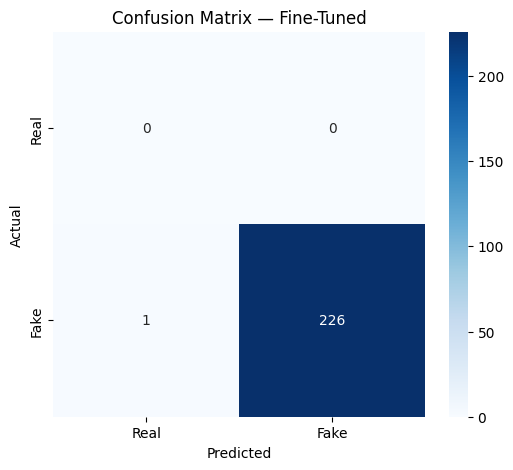

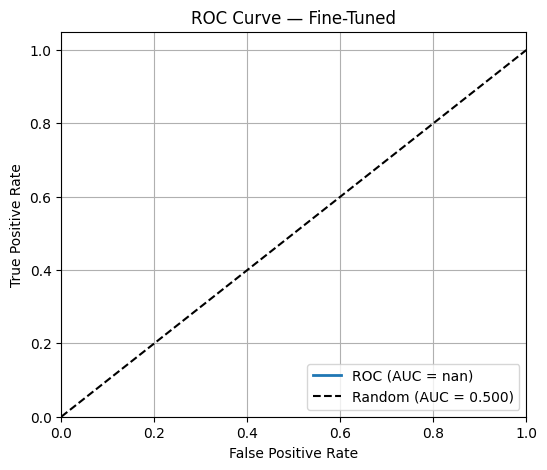

In [ ]:
# ============================
# Full Evaluation Script
# ============================

import torch
import numpy as np
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    f1_score,
)

# ----
# Make sure criterion exists
# ----
criterion = torch.nn.CrossEntropyLoss()

print("\n=== Evaluating fine-tuned model ===")
model.eval()

all_labels = []
all_preds = []
all_probs = []

eval_loss = 0.0
total_samples = 0

with torch.no_grad():
    for batch in tqdm(test_loader):
        images = batch["vit"].to(device)      # [B,3,224,224]
        labels = batch["labels"].to(device)   # [B]

        outputs = model(images)

        # DeiT distilled may output (logits, dist_logits) in some configs
        if isinstance(outputs, (tuple, list)):
            outputs = outputs[0]

        loss = criterion(outputs, labels)

        eval_loss += loss.item() * images.size(0)
        total_samples += labels.size(0)

        probs = torch.softmax(outputs, dim=1)[:, 1]   # P(class=1=Fake)
        preds = outputs.argmax(dim=1)

        all_labels.extend(labels.detach().cpu().numpy())
        all_preds.extend(preds.detach().cpu().numpy())
        all_probs.extend(probs.detach().cpu().numpy())

# ----
# Metrics
# ----
avg_loss = eval_loss / max(total_samples, 1)
acc = accuracy_score(all_labels, all_preds)
f1  = f1_score(all_labels, all_preds)  # positive class defaults to 1 in binary case

cm = confusion_matrix(all_labels, all_preds)  # rows=true, cols=pred
tn, fp, fn, tp = cm.ravel()

# Treat Fake (1) as positive
sensitivity = tp / (tp + fn + 1e-8)  # TPR
specificity = tn / (tn + fp + 1e-8)  # TNR
ppv = tp / (tp + fp + 1e-8)          # precision
npv = tn / (tn + fn + 1e-8)

# ROC + AUC
fpr, tpr, _ = roc_curve(all_labels, all_probs)  # positive class=1
roc_auc = roc_auc_score(all_labels, all_probs)

print("\n=== Results ===")
print(f"Accuracy: {acc * 100:.2f}%")
print(f"F1 (Fake=positive): {f1:.4f}")
print(f"AUC: {roc_auc:.4f}")
print(f"Sensitivity (Fake TPR): {sensitivity:.4f}")
print(f"Specificity (Fake TNR): {specificity:.4f}")
print(f"PPV (Fake Precision): {ppv:.4f}")
print(f"NPV: {npv:.4f}")
print(f"Average Loss: {avg_loss:.4f}\n")

print("Classification Report (0=Real, 1=Fake):")
print(classification_report(all_labels, all_preds, digits=4))

# ====================
# Confusion Matrix Plot
# ====================
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Real", "Fake"],
    yticklabels=["Real", "Fake"]
)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix — Fine-Tuned")
plt.show()

# ============
# ROC Curve Plot
# ============
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.500)")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Fine-Tuned")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


**Fine-Tune #4: Retrain on a 2000 image dataset (mix of OpenFake, Wildfake, Dragon, manual)** - building on existing model

In [3]:
from huggingface_hub import login
login()  # paste your HF token when prompted

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [4]:
# login into HF above, load model

import torch
import torch.nn as nn
from timm import create_model
from huggingface_hub import hf_hub_download

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Download weights
weights_path = hf_hub_download(
    repo_id="DeepFakeDetector/deit-distilled",
    filename="deit_distilled_custom_head.pt"
)

# Recreate the exact custom MLP head from your config
def build_head(in_features=768, num_classes=2):
    return nn.Sequential(
        nn.LayerNorm(in_features),
        nn.Linear(in_features, 512),
        nn.GELU(),
        nn.Dropout(p=0.2),
        nn.Linear(512, num_classes)
    )

# Build model
model = create_model("deit_base_distilled_patch16_224", pretrained=False)

# Replace BOTH heads with the same shared MLP (as per config note)
head = build_head()
model.head = head
if hasattr(model, "head_dist"):
    model.head_dist = head  # shared weights — same object

# Load weights
state_dict = torch.load(weights_path, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()

print("Model loaded successfully")

deit_distilled_custom_head.pt:   0%|          | 0.00/346M [00:00<?, ?B/s]

Model loaded successfully


In [7]:
import os, random
from pathlib import Path
import torch
from torch.utils.data import DataLoader, Subset, ConcatDataset, Dataset
from datasets import load_dataset

WILD_TRAIN = "/content/drive/MyDrive/datasets/wildfake_2k_split/train"
WILD_TEST  = "/content/drive/MyDrive/datasets/wildfake_2k_split/test"

OPEN_TRAIN = "/content/drive/MyDrive/datasets/OpenFake/train"
OPEN_TEST  = "/content/drive/MyDrive/datasets/OpenFake/test"

DRAG_TRAIN_A = "/content/drive/MyDrive/datasets/Dragon/train"
DRAG_TRAIN_B = "/content/drive/MyDrive/datasets/DRAGON/train"

MANUAL_HF_ID    = "DeepFakeDetector/manual-gen-images"
MANUAL_HF_SPLIT = "train"

BATCH_SIZE = 16
NUM_WORKERS = 2

N_TRAIN_WILD_REAL   = 800
N_TRAIN_OPEN_REAL   = 500
N_TRAIN_WILD_FAKE   = 100
N_TRAIN_OPEN_FAKE   = 100
N_TRAIN_DRAG_FAKE   = 250
N_TRAIN_MANUAL_FAKE = 250

N_TEST_WILD_REAL = 120
N_TEST_WILD_FAKE = 120
N_TEST_OPEN_REAL = 80
N_TEST_OPEN_FAKE = 80

VALID_EXT = {".jpg", ".jpeg", ".png", ".webp"}

def pick_existing_path(*paths):
    for p in paths:
        if os.path.isdir(p):
            return p
    raise RuntimeError(f"None of these paths exist: {paths}")

def make_local_subset(root: str, label: int, n: int):
    ds = PreprocDataset(root, max_images=None)
    idxs = [i for i, (_, y) in enumerate(ds.items) if y == label]
    random.shuffle(idxs)
    if n > len(idxs):
        raise ValueError(f"{root} label={label}: requested {n}, found {len(idxs)}")
    return Subset(ds, idxs[:n])

class HFPreprocSubset(Dataset):
    def __init__(self, hf_id: str, split: str, indices, force_label: int | None = 1):
        base = load_dataset(hf_id, split=split)
        self.ds = base.select(list(indices))
        self.force_label = force_label

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        ex = self.ds[idx]
        img = ex["image"]
        y = int(self.force_label) if self.force_label is not None else int(ex["label"])
        out = preprocess_pil(img)
        out["label"] = y
        return out

class AllFakeFolderDataset(Dataset):
    def __init__(self, root: str, max_images: int | None = None):
        root = Path(root)
        files = [p for p in root.rglob("*") if p.suffix.lower() in VALID_EXT]
        if not files:
            raise RuntimeError(f"No image files found under {root}")
        random.shuffle(files)
        if max_images is not None:
            files = files[:min(max_images, len(files))]
        self.files = [str(p) for p in files]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        out = preprocess_all(path)
        out["label"] = 1
        return out

# wild/open train subsets (real=0, fake=1)
wild_real_tr = make_local_subset(WILD_TRAIN, 0, N_TRAIN_WILD_REAL)
open_real_tr = make_local_subset(OPEN_TRAIN, 0, N_TRAIN_OPEN_REAL)

wild_fake_tr = make_local_subset(WILD_TRAIN, 1, N_TRAIN_WILD_FAKE)
open_fake_tr = make_local_subset(OPEN_TRAIN, 1, N_TRAIN_OPEN_FAKE)

# dragon fakes: folder scan, force label=1
DRAG_TRAIN = pick_existing_path(DRAG_TRAIN_A, DRAG_TRAIN_B)
drag_fake_tr = AllFakeFolderDataset(DRAG_TRAIN, max_images=N_TRAIN_DRAG_FAKE)

# manual HF: disjoint train/test indices, force label=1
hf_total = len(load_dataset(MANUAL_HF_ID, split=MANUAL_HF_SPLIT))
hf_idxs = list(range(hf_total))
random.shuffle(hf_idxs)

manual_tr_idxs = hf_idxs[:N_TRAIN_MANUAL_FAKE]
manual_te_idxs = hf_idxs[N_TRAIN_MANUAL_FAKE:N_TRAIN_MANUAL_FAKE + 50]

manual_fake_tr = HFPreprocSubset(MANUAL_HF_ID, MANUAL_HF_SPLIT, manual_tr_idxs, force_label=1)
manual_fake_te = HFPreprocSubset(MANUAL_HF_ID, MANUAL_HF_SPLIT, manual_te_idxs, force_label=1)

train_dataset = ConcatDataset([wild_real_tr, open_real_tr, wild_fake_tr, open_fake_tr, drag_fake_tr, manual_fake_tr])

# test: from test folders only (no overlap with train folders), plus small manual holdout
wild_real_te = make_local_subset(WILD_TEST, 0, N_TEST_WILD_REAL)
wild_fake_te = make_local_subset(WILD_TEST, 1, N_TEST_WILD_FAKE)

test_parts = [wild_real_te, wild_fake_te, manual_fake_te]

if os.path.isdir(OPEN_TEST):
    open_real_te = make_local_subset(OPEN_TEST, 0, N_TEST_OPEN_REAL)
    open_fake_te = make_local_subset(OPEN_TEST, 1, N_TEST_OPEN_FAKE)
    test_parts += [open_real_te, open_fake_te]

test_dataset = ConcatDataset(test_parts)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print("dragon path:", DRAG_TRAIN)
print("train:", len(train_dataset))
print("test :", len(test_dataset))

README.md:   0%|          | 0.00/1.67k [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


Resolving data files:   0%|          | 0/327 [00:00<?, ?it/s]

images/bing/p006.jpg:   0%|          | 0.00/200k [00:00<?, ?B/s]

images/bing/p001.jpg:   0%|          | 0.00/171k [00:00<?, ?B/s]

...

Repo card metadata block was not found. Setting CardData to empty.


Resolving data files:   0%|          | 0/327 [00:00<?, ?it/s]

Repo card metadata block was not found. Setting CardData to empty.


Resolving data files:   0%|          | 0/327 [00:00<?, ?it/s]

dragon path: /content/drive/MyDrive/datasets/DRAGON/train
train: 1977
test : 400


In [12]:
import torch
import torch.nn as nn
from torch.optim import AdamW

# make sure we're training (not eval)
model.train()

# unfreeze all params (same as your original run)
for p in model.parameters():
    p.requires_grad = True

# discriminative LR (same as your original)
backbone_params, head_params = [], []
for name, p in model.named_parameters():
    if name.startswith("head"):
        head_params.append(p)
    else:
        backbone_params.append(p)

optimizer = AdamW(
    [
        {"params": backbone_params, "lr": 2e-5},
        {"params": head_params,     "lr": 5e-5},
    ],
    weight_decay=1e-4,
)

criterion = nn.CrossEntropyLoss()
fine_tune_epochs = 4

print("ready to fine-tune")
print("backbone params:", sum(p.numel() for p in backbone_params))
print("head params:", sum(p.numel() for p in head_params))
print("lrs:", [pg["lr"] for pg in optimizer.param_groups], "wd:", optimizer.param_groups[0].get("weight_decay"))

ready to fine-tune
backbone params: 85800192
head params: 396290
lrs: [2e-05, 5e-05] wd: 0.0001


In [17]:
## Training new model
from tqdm import tqdm

print("\n=== Fine-Tuning DeiT-Base Distilled ===")

for epoch in range(fine_tune_epochs):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    print(f"\nEpoch {epoch+1}/{fine_tune_epochs}")

    for batch in tqdm(train_loader):
        images = batch["vit"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(images)

        # Distilled DeiT may return (logits, dist_logits) in training
        if isinstance(outputs, tuple):
            outputs = outputs[0]  # or (outputs[0] + outputs[1]) / 2

        loss = criterion(outputs, labels)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = running_correct / total_samples * 100
    print(f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.2f}%")



=== Fine-Tuning DeiT-Base Distilled ===

Epoch 1/4


100%|██████████| 124/124 [01:20<00:00,  1.54it/s]


Train Loss: 0.0009, Train Acc: 99.95%

Epoch 2/4


  1%|          | 1/124 [00:02<04:29,  2.19s/it]


KeyboardInterrupt: 


=== Evaluating fine-tuned model ===


100%|██████████| 25/25 [00:09<00:00,  2.51it/s]


=== Results ===
Accuracy: 90.75%
F1 (Fake=positive): 0.9013
AUC: 0.9689
Sensitivity (Fake TPR): 0.8450
Specificity (Fake TNR): 0.9700
PPV (Fake Precision): 0.9657
NPV: 0.8622
Average Loss: 0.6321

Classification Report (0=Real, 1=Fake):
              precision    recall  f1-score   support

           0     0.8622    0.9700    0.9129       200
           1     0.9657    0.8450    0.9013       200

    accuracy                         0.9075       400
   macro avg     0.9140    0.9075    0.9071       400
weighted avg     0.9140    0.9075    0.9071       400



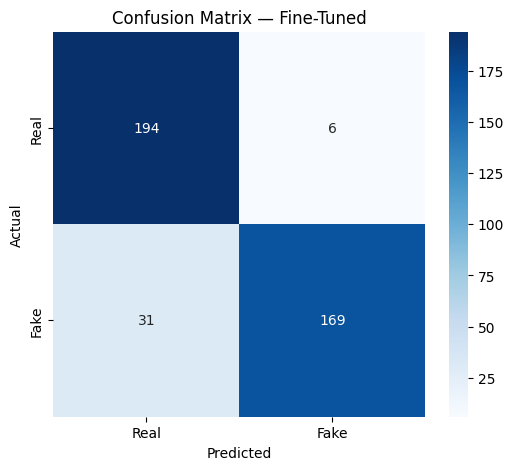

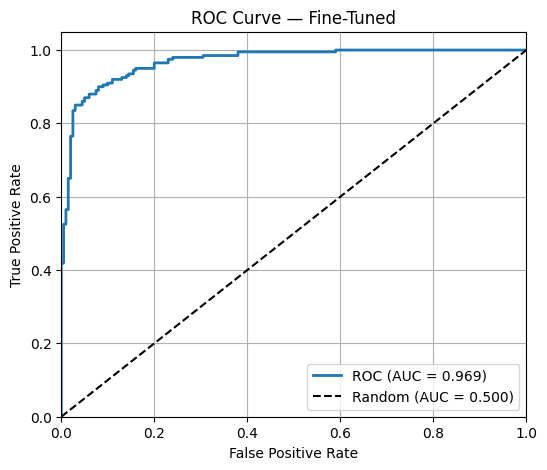

In [18]:
# ============================
# Full Evaluation Script
# ============================

import torch
import numpy as np
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    f1_score,
)

criterion = torch.nn.CrossEntropyLoss()

print("\n=== Evaluating fine-tuned model ===")
model.eval()

all_labels = []
all_preds = []
all_probs = []

eval_loss = 0.0
total_samples = 0

with torch.no_grad():
    for batch in tqdm(test_loader):
        images = batch["vit"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(images)

        # Average logits if distilled returns tuple
        if isinstance(outputs, (tuple, list)):
            outputs = (outputs[0] + outputs[1]) / 2

        loss = criterion(outputs, labels)

        eval_loss += loss.item() * images.size(0)
        total_samples += labels.size(0)

        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = outputs.argmax(dim=1)

        all_labels.extend(labels.detach().cpu().numpy())
        all_preds.extend(preds.detach().cpu().numpy())
        all_probs.extend(probs.detach().cpu().numpy())

avg_loss = eval_loss / max(total_samples, 1)
acc = accuracy_score(all_labels, all_preds)
f1  = f1_score(all_labels, all_preds)

cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn + 1e-8)
specificity = tn / (tn + fp + 1e-8)
ppv = tp / (tp + fp + 1e-8)
npv = tn / (tn + fn + 1e-8)

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = roc_auc_score(all_labels, all_probs)

print("\n=== Results ===")
print(f"Accuracy: {acc * 100:.2f}%")
print(f"F1 (Fake=positive): {f1:.4f}")
print(f"AUC: {roc_auc:.4f}")
print(f"Sensitivity (Fake TPR): {sensitivity:.4f}")
print(f"Specificity (Fake TNR): {specificity:.4f}")
print(f"PPV (Fake Precision): {ppv:.4f}")
print(f"NPV: {npv:.4f}")
print(f"Average Loss: {avg_loss:.4f}\n")

print("Classification Report (0=Real, 1=Fake):")
print(classification_report(all_labels, all_preds, digits=4))

# Confusion Matrix Plot
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Real", "Fake"],
    yticklabels=["Real", "Fake"]
)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix — Fine-Tuned")
plt.show()

# ROC Curve Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.500)")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Fine-Tuned")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [19]:
from huggingface_hub import login, HfApi
import torch

# login (needs write token)
login()

# Save current in-memory weights to a temp file
local_path = "deit_distilled_v2.pt"
torch.save(model.state_dict(), local_path)

# Upload to your existing repo
repo_id = "DeepFakeDetector/deit-distilled-retrained"

api = HfApi()
api.upload_file(
    path_or_fileobj=local_path,
    path_in_repo="deit_distilled_v2.pt",
    repo_id=repo_id,
    repo_type="model",
)

print("Uploaded deit_distilled_v2.pt to HF")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  deit_distilled_v2.pt        :   0%|          |  551kB /  345MB            

Uploaded deit_distilled_v2.pt to HF


In [ ]:
# ============================================================
# Save DeiT distilled artifacts to Google Drive (models/ base)
# ============================================================

from google.colab import drive
from pathlib import Path
import json
import torch

# 1. Mount Google Drive (run once per session)
drive.mount("/content/drive")

# 2. Base models directory in Google Drive
OUT_DIR = Path("/content/drive/MyDrive/DeepFakeDetector/models")
OUT_DIR.mkdir(parents=True, exist_ok=True)

weights_path = OUT_DIR / "weights.pt"
config_path  = OUT_DIR / "config.json"

# 3. Save model weights (state_dict only)
torch.save(model.state_dict(), weights_path)

# 4. Save config.json
config = {
    "model_name": "deit_base_distilled_patch16_224",
    "library": "timm",
    "input_size": 224,
    "num_classes": 2,
    "class_mapping": {
        "0": "real",
        "1": "fake"
    },
    "distilled": True,

    # Matches your training/eval logic
    "logits_handling": "first",

    "normalization": {
        "scheme": "imagenet",
        "mean": [0.485, 0.456, 0.406],
        "std":  [0.229, 0.224, 0.225]
    },

    "head": {
        "type": "mlp",
        "hidden_dim": 512,
        "dropout": 0.2
    }
}

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

print("✅ Saved to Google Drive base models folder:")
print("Weights:", weights_path)
print("Config :", config_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Saved to Google Drive base models folder:
Weights: /content/drive/MyDrive/DeepFakeDetector/models/weights.pt
Config : /content/drive/MyDrive/DeepFakeDetector/models/config.json
